In [3]:
import os
import time
import warnings
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
%matplotlib inline

from sgimc.utils import save, load

In [4]:
PATH_ROOT = "/Users/sijianfan/Documents/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/tuberculosis/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/realAnalysis/tuberculosis")
if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

In [5]:
def get_final_results(results, param="train_size", hyp_param="C_group"):
    # grouping by validation
    id_result = {}
    param_ids = defaultdict(list)

    for _id, result in enumerate(results):
        comb = "{}|{}".format(result[param], result[hyp_param])
        param_ids[comb].append(_id)

        id_result[_id] = [
            result[param],
            result[hyp_param],
            result["val_score"],
            result["test_score"],
        ]

    id_groups = list(param_ids.values())

    # averaging the cross-validation results
    results_avg = []

    for ids in id_groups:
        val_res = [id_result[_id] for _id in ids]
        avg_res = np.mean(val_res, axis=0)
        results_avg.append(avg_res)

    results_avg = np.array(results_avg)

    # grouping by train_size
    id_result = {}
    param_ids = defaultdict(list)

    for _id, val_res in enumerate(results_avg):
        comb = "{}".format(val_res[0])
        param_ids[comb].append(_id)

        id_result[_id] = val_res[[0, 2, 3]]

    id_groups = list(param_ids.values())

    results_final = []

    for ids in id_groups:
        param_res = results_avg[ids]
        val = [x[2] for x in param_res]
        chosen_result = param_res[np.argmax(val)]
        results_final.append(chosen_result[[0, 3]])

    results_final = np.array(results_final)

    return results_final.T

## SGIMC

In [5]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_sgimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_sgimc.gz']

## BiSSGL

In [6]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/Documents/projects/BiSSGL/outputs/realAnalysis/tuberculosis/results_bissgl.gz']

In [10]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [11]:
results

[[{'combo_idx': 0,
   'train_size': 0.001,
   'xi': 1,
   'eta': 5e-06,
   'tilde_lambda0': 5,
   'lambda0': 5,
   'K': 5,
   'cv': 0,
   'val_score': 0.5688888888888889,
   'val_d1': 9141,
   'val_d2': 29,
   'test_score': 0.7247805483531892,
   'test_d1': 9200,
   'test_d2': 25},
  {'combo_idx': 0,
   'train_size': 0.001,
   'xi': 1,
   'eta': 5e-06,
   'tilde_lambda0': 5,
   'lambda0': 5,
   'K': 5,
   'cv': 1,
   'val_score': 0.6985645933014355,
   'val_d1': 9238,
   'val_d2': 26,
   'test_score': 0.7247805483531892,
   'test_d1': 9200,
   'test_d2': 25},
  {'combo_idx': 0,
   'train_size': 0.001,
   'xi': 1,
   'eta': 5e-06,
   'tilde_lambda0': 5,
   'lambda0': 5,
   'K': 5,
   'cv': 2,
   'val_score': 0.6220095693779905,
   'val_d1': 9247,
   'val_d2': 25,
   'test_score': 0.7247805483531892,
   'test_d1': 9200,
   'test_d2': 25},
  {'combo_idx': 1,
   'train_size': 0.001,
   'xi': 2,
   'eta': 5e-06,
   'tilde_lambda0': 5,
   'lambda0': 5,
   'K': 5,
   'cv': 0,
   'val_score': 

In [ ]:
results_final = []
for result in results:
    results_final.append(get_final_results(result, param="xi", hyp_param="train_size"))
results_final = np.array(results_final)
results_bissgl = np.mean(results_final, axis=0)

In [21]:
print(results_final, "\n", results_bissgl)

[[[ 1.          2.          5.         10.        ]
  [ 0.63012468  0.77996786  0.66537092  0.62951056]]] 
 [[ 1.          2.          5.         10.        ]
 [ 0.63012468  0.77996786  0.66537092  0.62951056]]


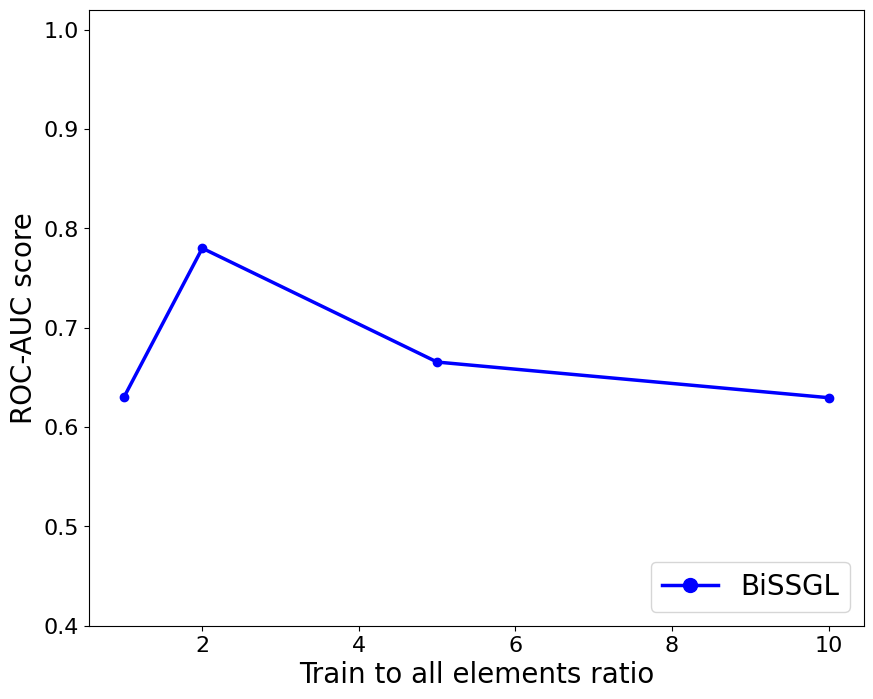

In [22]:
plt.figure(figsize=(10, 8))

# lines
bissgl_line = mlines.Line2D(
    [], [], color="blue", marker="o", linewidth=2.5, markersize=10, label="BiSSGL"
)
# imc_line = mlines.Line2D([], [], color='red', marker='s', linewidth=2.5,
#                          markersize=10, label='IMC')
# mf_line = mlines.Line2D([], [], color='green', marker='^', linewidth=2.5,
#                         markersize=10, label='MF')
# sgimc_comb_line = mlines.Line2D([], [], color='blue', marker='o', linewidth=2.5, linestyle='--',
#                                 markersize=10, label='SGIMC-comb')
# imc_comb_line = mlines.Line2D([], [], color='red', marker='s', linewidth=2.5, linestyle='--',
#                               markersize=10, label='IMC-comb')

# curves
plt.plot(results_bissgl[0], results_bissgl[1], "b-", label="BiSSGL", linewidth=2.5)
# plt.plot(results_imc[0], results_imc[1], 'r-', label='IMC', linewidth=2.5)
# plt.plot(results_mf[0], results_mf[1], 'g-', label='MF', linewidth=2.5)
# plt.plot(results_bissgl_comb[0], results_bissgl_comb[1], 'b--', label='SGIMC-comb', linewidth=2.5)
# plt.plot(results_imc_comb[0], results_imc_comb[1], 'r--', label='IMC-comb', linewidth=2.5)

# dotes
plt.plot(results_bissgl[0], results_bissgl[1], "bo", label="BiSSGL", linewidth=2.5)
# plt.plot(results_imc[0], results_imc[1], 'rs', label='IMC', linewidth=2.5)
# plt.plot(results_mf[0], results_mf[1], 'g^', label='MF', linewidth=2.5)
# plt.plot(results_bissgl_comb[0], results_bissgl_comb[1], 'bo', label='SGIMC-comb', linewidth=2.5)
# plt.plot(results_imc_comb[0], results_imc_comb[1], 'rs', label='IMC-comb', linewidth=2.5)

# specify axis limits and labels
plt.ylim((0.4, 1.02))
plt.xlabel("Train to all elements ratio", fontsize=20)
plt.ylabel("ROC-AUC score", fontsize=20)

# ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# legend
plt.legend(
    handles=[
        bissgl_line,  # imc_line, mf_line, sgimc_comb_line, imc_comb_line
    ],
    fontsize=20,
    loc=4,
)

plt.show()